In [1]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


Dataset Shape: (15420, 33)


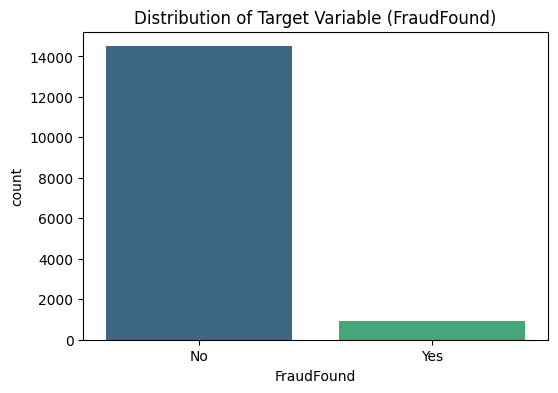

Target Variable Percentage:
FraudFound
No     94.014267
Yes     5.985733
Name: proportion, dtype: float64


In [2]:
# 2. Load the dataset
df = pd.read_csv('carclaims.csv')

# Display basic information
print(f"Dataset Shape: {df.shape}")

# Visualizing the target variable imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='FraudFound', data=df, palette='viridis')
plt.title('Distribution of Target Variable (FraudFound)')
plt.show()

# Display value counts percentage
print("Target Variable Percentage:")
print(df['FraudFound'].value_counts(normalize=True) * 100)

In [4]:
# 3. Data Cleaning
df_clean = df.copy()

# A. Rename target to match task description and encode as 1 and 0
df_clean = df_clean.rename(columns={'FraudFound': 'FraudFound_P'})
df_clean['FraudFound_P'] = df_clean['FraudFound_P'].map({'Yes': 1, 'No': 0})

# B. Drop unnecessary columns (PolicyNumber is unique for everyone, acts like ID)
df_clean = df_clean.drop(['PolicyNumber', 'RepNumber'], axis=1)

# C. Handle irrational values (e.g., Age = 0)
# We will replace 0 with the median age of the dataset
median_age = df_clean[df_clean['Age'] > 0]['Age'].median()
df_clean.loc[df_clean['Age'] == 0, 'Age'] = median_age

print("Data Cleaning Completed!")

Data Cleaning Completed!


In [5]:
# 4. Encoding Categorical Variables
# We use LabelEncoder to convert text columns into numerical values
label_encoders = {}
categorical_columns = df_clean.select_dtypes(include=['object']).columns

for col in categorical_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le # Save encoders if needed for later decoding

print("Categorical features encoded successfully.")
df_clean.head()

Categorical features encoded successfully.


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound_P
0,2,5,6,6,1,6,5,1,0,2,...,3,0,0,0,3,0,2,1994,2,0
1,4,3,6,6,1,2,5,4,1,2,...,4,1,0,0,3,3,0,1994,1,0
2,10,5,0,6,1,5,10,2,1,1,...,6,0,0,0,3,3,0,1994,1,0
3,6,2,2,17,0,1,6,1,1,1,...,7,1,0,0,2,3,0,1994,2,0
4,4,5,1,6,1,6,4,2,0,2,...,4,0,0,0,3,3,0,1994,1,0


In [6]:
# 5. Define Features (X) and Target (y)
X = df_clean.drop('FraudFound_P', axis=1)
y = df_clean['FraudFound_P']

# Split the data into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE ONLY to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original Training shape: {X_train.shape}")
print(f"Training shape after SMOTE: {X_train_smote.shape}")

Original Training shape: (12336, 30)
Training shape after SMOTE: (23196, 30)


In [9]:
# 6. Model Training & Comparison

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

print("Starting to train 4 different models. Please wait...")

# Model 1: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
rf_pred = rf_model.predict(X_test)
print("- Random Forest: Done!")

# Model 2: Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_smote, y_train_smote)
gb_pred = gb_model.predict(X_test)
print("- Gradient Boosting: Done!")

# Model 3: XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_pred = xgb_model.predict(X_test)
print("- XGBoost: Done!")

# Model 4: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)
lr_pred = lr_model.predict(X_test)
print("- Logistic Regression: Done!")

print("\nAll 4 Models Trained Successfully!")

Starting to train 4 different models. Please wait...
- Random Forest: Done!
- Gradient Boosting: Done!
- XGBoost: Done!
- Logistic Regression: Done!

All 4 Models Trained Successfully!


       MODELS PERFORMANCE COMPARISON

1. RANDOM FOREST:
Accuracy: 0.9085603112840467
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2899
           1       0.19      0.17      0.18       185

    accuracy                           0.91      3084
   macro avg       0.57      0.56      0.57      3084
weighted avg       0.90      0.91      0.91      3084


2. GRADIENT BOOSTING:
Accuracy: 0.8200389105058365
              precision    recall  f1-score   support

           0       0.96      0.84      0.90      2899
           1       0.16      0.48      0.24       185

    accuracy                           0.82      3084
   macro avg       0.56      0.66      0.57      3084
weighted avg       0.91      0.82      0.86      3084


3. XGBOOST:
Accuracy: 0.9020752269779507
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      2899
           1       0.21      0.23      0.22       185

   

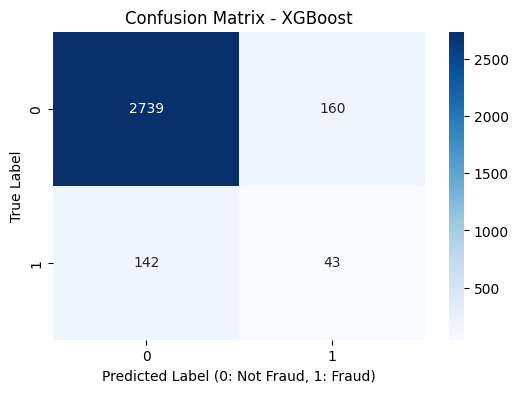

In [10]:
# 7. Model Evaluation Comparison

print("="*40)
print("       MODELS PERFORMANCE COMPARISON")
print("="*40)

print("\n1. RANDOM FOREST:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

print("\n2. GRADIENT BOOSTING:")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

print("\n3. XGBOOST:")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

print("\n4. LOGISTIC REGRESSION:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# Confusion Matrix for the traditionally best model (XGBoost or RF)
# Here we plot XGBoost as an example
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Label (0: Not Fraud, 1: Fraud)')
plt.ylabel('True Label')
plt.show()

In [11]:
# 8. Save the Model and the Encoders using Pickle
# We save the model to use it in our FastAPI backend later

model_data = {
    "model": rf_model,
    "encoders": label_encoders, # Important: we save encoders to transform API user input later
    "features": list(X.columns)
}

with open("fraud_detection_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Best model saved as 'fraud_detection_model.pkl' successfully!")

Best model saved as 'fraud_detection_model.pkl' successfully!
